[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dz-web3/DS-Tech-2026spring/blob/main/Module7_LLM_Finetuning/LLM_Finetuning.ipynb)

# Module 7: Fine-Tuning Large Language Models (LLMs)

**Data Science for Business (Technical) — Spring 2026**

---

## Learning Objectives

By the end of this module, you will be able to:

1. **Explain** the difference between pre-training, fine-tuning, and prompting
2. **Understand** when fine-tuning is the right choice vs. other approaches
3. **Perform** hands-on fine-tuning using Hugging Face and LoRA
4. **Visualize** training loss and detect overfitting
5. **Measure** improvement using before/after evaluation on held-out test data

---

## Why This Matters for Business

Large Language Models like GPT-4, Claude, and Qwen are transforming how businesses operate. But **off-the-shelf models don't always fit your specific needs**. Fine-tuning allows you to:

- **Customize** model behavior for your domain (legal, medical, customer service)
- **Reduce costs** by using smaller, specialized models instead of expensive large ones
- **Maintain control** over your data and model behavior
- **Improve performance** on specific tasks your business cares about

## 1. Setting Up Google Colab

### Enabling GPU

Fine-tuning requires a GPU. To enable it:

1. Go to **Runtime** > **Change runtime type**
2. Set **Hardware accelerator** to **T4 GPU** (or A100 if available)
3. Click **Save**

### Setting Up Your Hugging Face Account

Hugging Face is where open-source AI models are hosted (think of it as GitHub for AI models). You need a free account and an access token to download models.

**Step 1 — Create an account**: Go to [huggingface.co](https://huggingface.co) and click **Sign Up** (you can use your Google account).

**Step 2 — Create an access token**:
1. Go to [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)
2. Click **Create new token**
3. Name it (e.g., "colab"), select **Read** access, click **Generate**
4. Copy the token (starts with `hf_...`)

**Step 3 — Store the token in Colab**:
1. In Colab, click the **key icon** (Secrets) in the left sidebar
2. Click **Add new secret**
3. Set the name to exactly `HF_TOKEN` and paste your token as the value
4. Toggle **Notebook access** to ON

Now run the cells below to verify everything is set up.

In [1]:
# --- Step 1: Check GPU ---
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU is enabled: {gpu_name}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: GPU is NOT enabled.")
    print("Go to Runtime > Change runtime type > Select T4 GPU, then re-run this cell.")

GPU is enabled: NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory: 102.0 GB


In [2]:
# --- Step 2: Install libraries (takes ~1 minute) ---
!pip install transformers datasets peft accelerate huggingface_hub matplotlib -q
print("Libraries installed.")

Libraries installed.


In [3]:
# --- Step 3: Log in to Hugging Face ---
from huggingface_hub import login
from google.colab import userdata

try:
    hf_token = userdata.get("HF_TOKEN")
    login(token=hf_token, add_to_git_credential=False)
    print("Logged in to Hugging Face.")
except Exception:
    print("HF_TOKEN secret not found. Please follow the setup instructions above:")
    print("  1. Get a token at https://huggingface.co/settings/tokens")
    print("  2. Click the key icon in Colab's left sidebar")
    print("  3. Add a secret named HF_TOKEN with your token")
    print("  4. Toggle 'Notebook access' on, then re-run this cell")

Logged in to Hugging Face.


## 2. The LLM Customization Spectrum

Before diving into fine-tuning, let's understand where it fits in the broader landscape of LLM customization:

| Approach | Effort | Data Needed | Use Case |
|----------|--------|-------------|----------|
| **Prompting** | Low | None | Quick tasks, general use |
| **Few-shot Learning** | Low | 5-20 examples | Demonstrate desired format |
| **RAG** (Retrieval) | Medium | Documents | Add knowledge, keep model current |
| **Fine-tuning** | High | 100-10,000+ examples | Change model behavior/style |
| **Pre-training** | Very High | Billions of tokens | Build from scratch (rarely needed) |

### When Should You Fine-Tune?

 **Fine-tune when you want to:**
- Change the model's communication style consistently
- Make the model follow specific formats/templates
- Teach domain-specific terminology or behavior
- Improve reliability on repetitive tasks

 **Don't fine-tune when you can:**
- Solve the problem with better prompts
- Use RAG to add relevant knowledge
- Use few-shot examples in the prompt

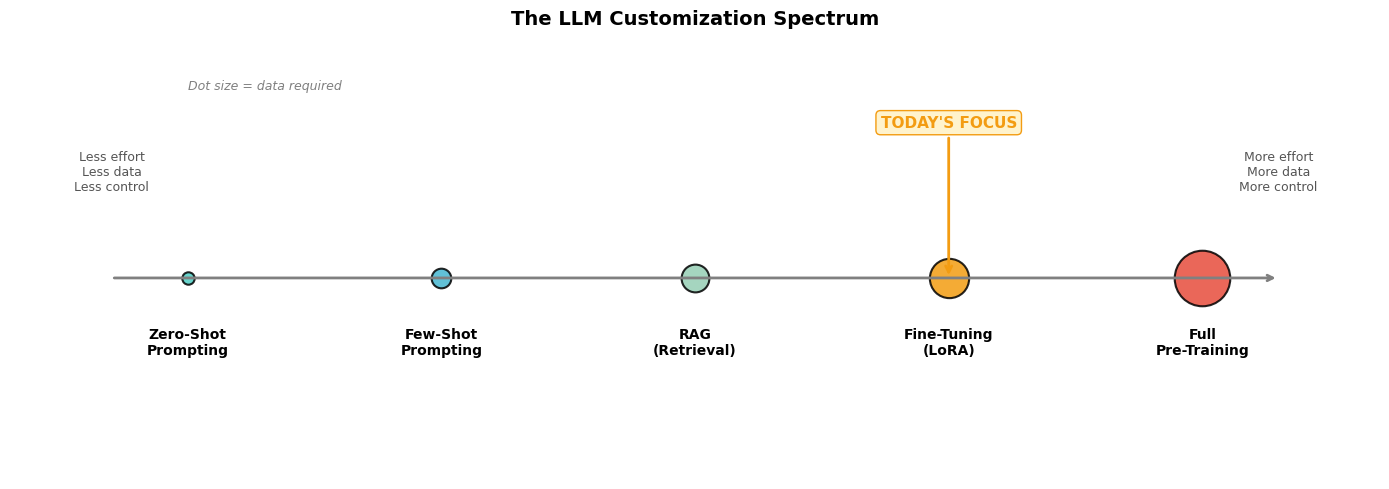

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 5))

# Define the spectrum
approaches = ['Zero-Shot\nPrompting', 'Few-Shot\nPrompting', 'RAG\n(Retrieval)', 'Fine-Tuning\n(LoRA)', 'Full\nPre-Training']
effort =     [1,                      2,                     3,                  4,                    5]
data_needed = [0,                      50,                   200,                800,                  3000]
colors =     ['#4ecdc4',              '#45b7d1',            '#96ceb4',          '#f39c12',            '#e74c3c']

# Normalize data_needed for dot sizes
sizes = [max(d, 80) for d in [80, 200, 400, 800, 1600]]

# Plot
for i, (name, e, s, c) in enumerate(zip(approaches, effort, sizes, colors)):
    ax.scatter(i, 0, s=s, c=c, alpha=0.85, edgecolors='black', linewidth=1.5, zorder=3)
    ax.annotate(name, (i, 0), textcoords="offset points", xytext=(0, -55),
                ha='center', fontsize=10, fontweight='bold')

# Arrow showing progression
ax.annotate('', xy=(4.3, 0), xytext=(-0.3, 0),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

# Labels
ax.text(-0.3, 0.35, 'Less effort\nLess data\nLess control', fontsize=9, ha='center', color='#555')
ax.text(4.3, 0.35, 'More effort\nMore data\nMore control', fontsize=9, ha='center', color='#555')

# Today's focus
ax.annotate('TODAY\'S FOCUS', xy=(3, 0), xytext=(3, 0.6),
            arrowprops=dict(arrowstyle='->', color='#f39c12', lw=2),
            fontsize=11, fontweight='bold', color='#f39c12', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd', edgecolor='#f39c12'))

ax.set_xlim(-0.7, 4.7)
ax.set_ylim(-0.8, 0.9)
ax.axis('off')
ax.set_title('The LLM Customization Spectrum', fontsize=14, fontweight='bold', pad=20)

# Legend for dot size
ax.text(0, 0.75, 'Dot size = data required', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

## 3. Understanding Fine-Tuning: The Concept

### Pre-training vs Fine-tuning

**Pre-training** is like giving someone a general education:
- The model learns from massive amounts of text (books, websites, code)
- It learns language patterns, facts, and reasoning
- This is expensive: millions of dollars, weeks of compute time
- Done by companies like Alibaba (Qwen), Meta (Llama), OpenAI (GPT), Google (Gemini)

**Fine-tuning** is like specialized job training:
- Start with a pre-trained model that already "knows" language
- Train it on your specific examples to learn your style/domain
- Much cheaper: can be done in minutes to hours on a single GPU
- This is what **you** can do!

### LoRA: Efficient Fine-Tuning

Traditional fine-tuning updates **all** model parameters — expensive and slow.

**LoRA (Low-Rank Adaptation)** is a clever technique that:
- Freezes the original model weights
- Adds small "adapter" layers that learn your specific task
- Only trains ~1% of the parameters
- Result: **Same quality, 10x less memory, 10x faster!**

Think of it like this: instead of rewriting an entire textbook, you're adding sticky notes with your customizations.

### Key Terms for This Module

| Term | What it means |
|------|--------------|
| **Parameters** | The numerical "knobs" inside a model that determine its behavior. A 0.5B model has 500 million of them. Fine-tuning adjusts these knobs to improve performance on your task. |
| **Loss** | A number measuring how wrong the model's predictions are. Lower = better. Think of it as an "error score" — during training we want loss to decrease, meaning the model is making fewer mistakes. |
| **Epoch** | One complete pass through all the training data. If you have 100 examples and train for 3 epochs, the model sees each example 3 times total. |
| **Learning rate** | How big a step the model takes when adjusting its parameters. Too large and it overshoots; too small and it learns too slowly. |
| **Tokenizer** | Converts text into numbers the model can process. The word "customer" might become token #4521. Think of it as a translator between human language and the model's internal language. |
| **Overfitting** | When the model memorizes the training data rather than learning general patterns. Like a student who memorizes answers instead of understanding the material — they score perfectly on practice questions but poorly on the exam. |

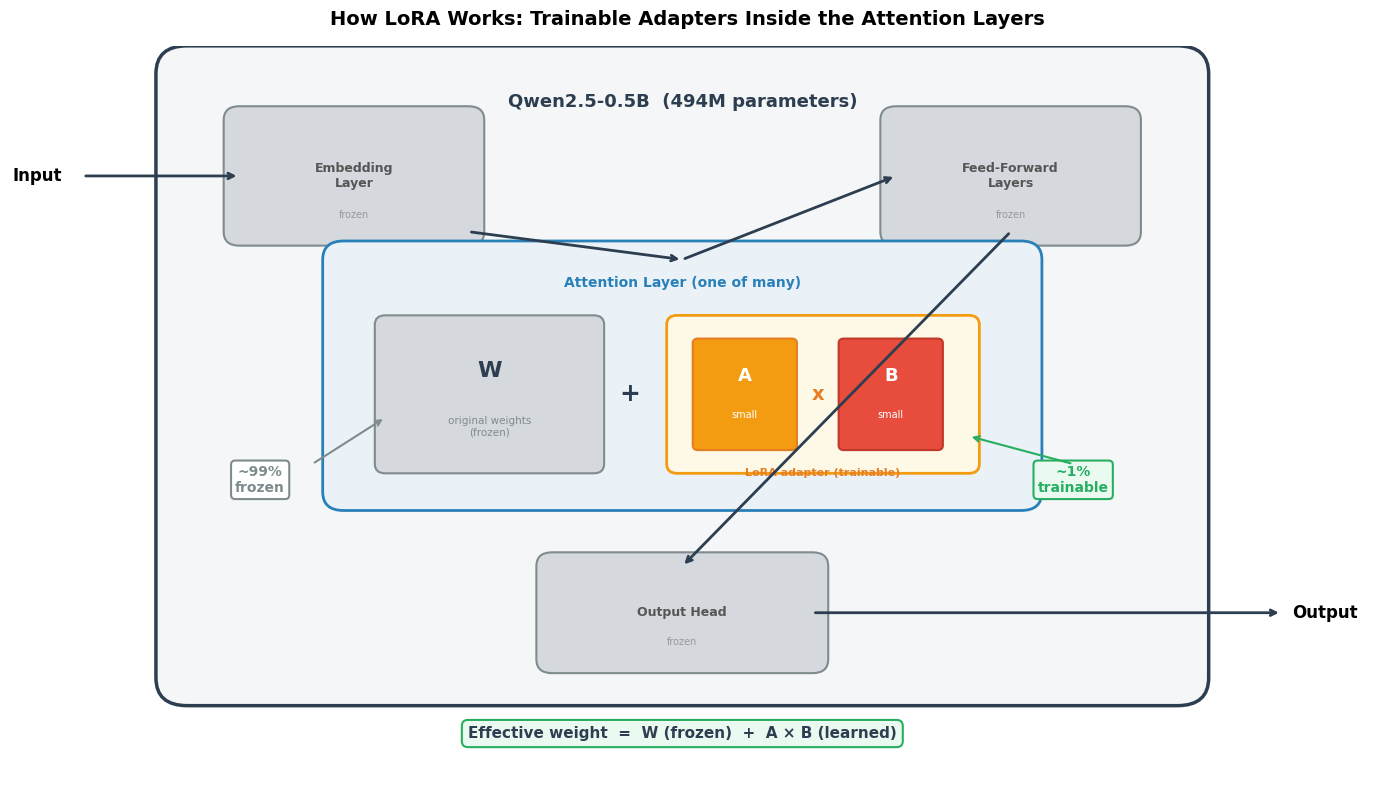

Key idea: LoRA injects small trainable matrices (A × B) INSIDE each attention layer.
The original weight matrix W stays frozen. The effective weight becomes W + A×B.
Only A and B are updated during training — that's ~1% of total parameters.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))

# ============================================================
# THE MODEL — large outer box representing the full transformer
# ============================================================
model_rect = mpatches.FancyBboxPatch((1.5, 1.0), 9.5, 6.5, boxstyle="round,pad=0.3",
                                      facecolor='#f4f6f7', edgecolor='#2c3e50', linewidth=2.5)
ax.add_patch(model_rect)
ax.text(6.25, 7.2, 'Qwen2.5-0.5B  (494M parameters)', fontsize=13, ha='center', va='center',
        fontweight='bold', color='#2c3e50')

# ============================================================
# FROZEN LAYERS — other parts of the transformer (most of it)
# ============================================================
# Embedding layer
embed = mpatches.FancyBboxPatch((2.0, 5.8), 2.2, 1.2, boxstyle="round,pad=0.15",
                                 facecolor='#d5d8dc', edgecolor='#7f8c8d', linewidth=1.5)
ax.add_patch(embed)
ax.text(3.1, 6.4, 'Embedding\nLayer', fontsize=9, ha='center', va='center', fontweight='bold', color='#555')
ax.text(3.1, 5.95, 'frozen', fontsize=7, ha='center', color='#999')

# Feed-forward layer
ff = mpatches.FancyBboxPatch((8.3, 5.8), 2.2, 1.2, boxstyle="round,pad=0.15",
                              facecolor='#d5d8dc', edgecolor='#7f8c8d', linewidth=1.5)
ax.add_patch(ff)
ax.text(9.4, 6.4, 'Feed-Forward\nLayers', fontsize=9, ha='center', va='center', fontweight='bold', color='#555')
ax.text(9.4, 5.95, 'frozen', fontsize=7, ha='center', color='#999')

# Output head
head = mpatches.FancyBboxPatch((5.0, 1.2), 2.5, 1.0, boxstyle="round,pad=0.15",
                                facecolor='#d5d8dc', edgecolor='#7f8c8d', linewidth=1.5)
ax.add_patch(head)
ax.text(6.25, 1.7, 'Output Head', fontsize=9, ha='center', va='center', fontweight='bold', color='#555')
ax.text(6.25, 1.35, 'frozen', fontsize=7, ha='center', color='#999')

# ============================================================
# ATTENTION LAYER — the one layer we zoom into
# ============================================================
attn_rect = mpatches.FancyBboxPatch((3.0, 3.0), 6.5, 2.5, boxstyle="round,pad=0.2",
                                     facecolor='#eaf2f8', edgecolor='#2980b9', linewidth=2)
ax.add_patch(attn_rect)
ax.text(6.25, 5.25, 'Attention Layer (one of many)', fontsize=10, ha='center', va='center',
        fontweight='bold', color='#2980b9')

# --- Original weight matrix W (frozen) ---
w_rect = mpatches.FancyBboxPatch((3.4, 3.3), 2.0, 1.5, boxstyle="round,pad=0.1",
                                  facecolor='#d5d8dc', edgecolor='#7f8c8d', linewidth=1.5)
ax.add_patch(w_rect)
ax.text(4.4, 4.3, 'W', fontsize=16, ha='center', va='center', fontweight='bold', color='#2c3e50')
ax.text(4.4, 3.7, 'original weights\n(frozen)', fontsize=7.5, ha='center', va='center', color='#7f8c8d')

# --- LoRA adapter (A and B, trainable) ---
lora_rect = mpatches.FancyBboxPatch((6.2, 3.3), 2.8, 1.5, boxstyle="round,pad=0.1",
                                     facecolor='#fef9e7', edgecolor='#f39c12', linewidth=2)
ax.add_patch(lora_rect)

# Matrix A (small)
a_rect = mpatches.FancyBboxPatch((6.4, 3.5), 0.9, 1.1, boxstyle="round,pad=0.05",
                                  facecolor='#f39c12', edgecolor='#e67e22', linewidth=1.5)
ax.add_patch(a_rect)
ax.text(6.85, 4.25, 'A', fontsize=13, ha='center', va='center', fontweight='bold', color='white')
ax.text(6.85, 3.8, 'small', fontsize=7, ha='center', color='white')

# Multiply sign
ax.text(7.55, 4.05, 'x', fontsize=14, ha='center', va='center', fontweight='bold', color='#e67e22')

# Matrix B (small)
b_rect = mpatches.FancyBboxPatch((7.8, 3.5), 0.9, 1.1, boxstyle="round,pad=0.05",
                                  facecolor='#e74c3c', edgecolor='#c0392b', linewidth=1.5)
ax.add_patch(b_rect)
ax.text(8.25, 4.25, 'B', fontsize=13, ha='center', va='center', fontweight='bold', color='white')
ax.text(8.25, 3.8, 'small', fontsize=7, ha='center', color='white')

ax.text(7.6, 3.2, 'LoRA adapter (trainable)', fontsize=8, ha='center', va='center',
        fontweight='bold', color='#e67e22')

# --- Plus sign between W and LoRA ---
ax.text(5.75, 4.05, '+', fontsize=18, ha='center', va='center', fontweight='bold', color='#2c3e50')

# ============================================================
# ARROWS — data flow through the model
# ============================================================
arrow_kw = dict(arrowstyle='->', lw=2)

# Input → Embedding
ax.annotate('', xy=(2.0, 6.4), xytext=(0.5, 6.4),
            arrowprops=dict(**arrow_kw, color='#2c3e50'))
ax.text(0.3, 6.4, 'Input', fontsize=12, ha='right', va='center', fontweight='bold')

# Embedding → Attention
ax.annotate('', xy=(6.25, 5.5), xytext=(4.2, 5.8),
            arrowprops=dict(**arrow_kw, color='#2c3e50'))

# Attention → Feed-Forward
ax.annotate('', xy=(8.3, 6.4), xytext=(6.25, 5.5),
            arrowprops=dict(**arrow_kw, color='#2c3e50'))

# Feed-Forward → Output Head
ax.annotate('', xy=(6.25, 2.2), xytext=(9.4, 5.8),
            arrowprops=dict(**arrow_kw, color='#2c3e50'))

# Output Head → Output
ax.annotate('', xy=(12.0, 1.7), xytext=(7.5, 1.7),
            arrowprops=dict(**arrow_kw, color='#2c3e50'))
ax.text(12.1, 1.7, 'Output', fontsize=12, ha='left', va='center', fontweight='bold')

# ============================================================
# FORMULA — W + A*B
# ============================================================
ax.text(6.25, 0.4, 'Effective weight  =  W (frozen)  +  A × B (learned)',
        fontsize=11, ha='center', va='center', fontweight='bold', color='#2c3e50',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#eafaf1', edgecolor='#27ae60', linewidth=1.5))

# ============================================================
# ANNOTATIONS
# ============================================================
# "~1% trainable" badge
ax.text(10.0, 3.0, '~1%\ntrainable', fontsize=10, ha='center', fontweight='bold', color='#27ae60',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#27ae60', linewidth=1.5))
ax.annotate('', xy=(9.0, 3.6), xytext=(10.0, 3.3),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

# "~99% frozen" badge
ax.text(2.2, 3.0, '~99%\nfrozen', fontsize=10, ha='center', fontweight='bold', color='#7f8c8d',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#7f8c8d', linewidth=1.5))
ax.annotate('', xy=(3.4, 3.8), xytext=(2.7, 3.3),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))

ax.set_xlim(-0.2, 12.8)
ax.set_ylim(-0.1, 7.8)
ax.axis('off')
ax.set_title('How LoRA Works: Trainable Adapters Inside the Attention Layers',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("Key idea: LoRA injects small trainable matrices (A × B) INSIDE each attention layer.")
print("The original weight matrix W stays frozen. The effective weight becomes W + A×B.")
print("Only A and B are updated during training — that's ~1% of total parameters.")

## 4. Hands-On: Fine-Tuning Qwen2.5

Now let's actually fine-tune a model! Here is what we will do:

1. **Load** a pre-trained model (Qwen2.5-0.5B — a small but capable LLM from Alibaba)
2. **Evaluate BEFORE**: ask it to classify customer messages → see how it performs out-of-the-box
3. **Fine-tune** with LoRA on 100 labeled customer messages
4. **Evaluate AFTER**: the model now reliably outputs the correct category
5. **Visualize** the improvement with accuracy charts and a confusion matrix

### The Task: Customer Message Classification

Companies receive thousands of customer messages daily. Routing them to the right department (Shipping, Returns, Billing, etc.) is a real business problem. We will teach the model to do this automatically.

**Before fine-tuning**: The base model may produce verbose responses or inconsistent labels.

**After fine-tuning**: The model learns to output just the correct category — like a well-trained employee who instantly knows which department handles each message.

/tmp/ipykernel_8516/1229171147.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


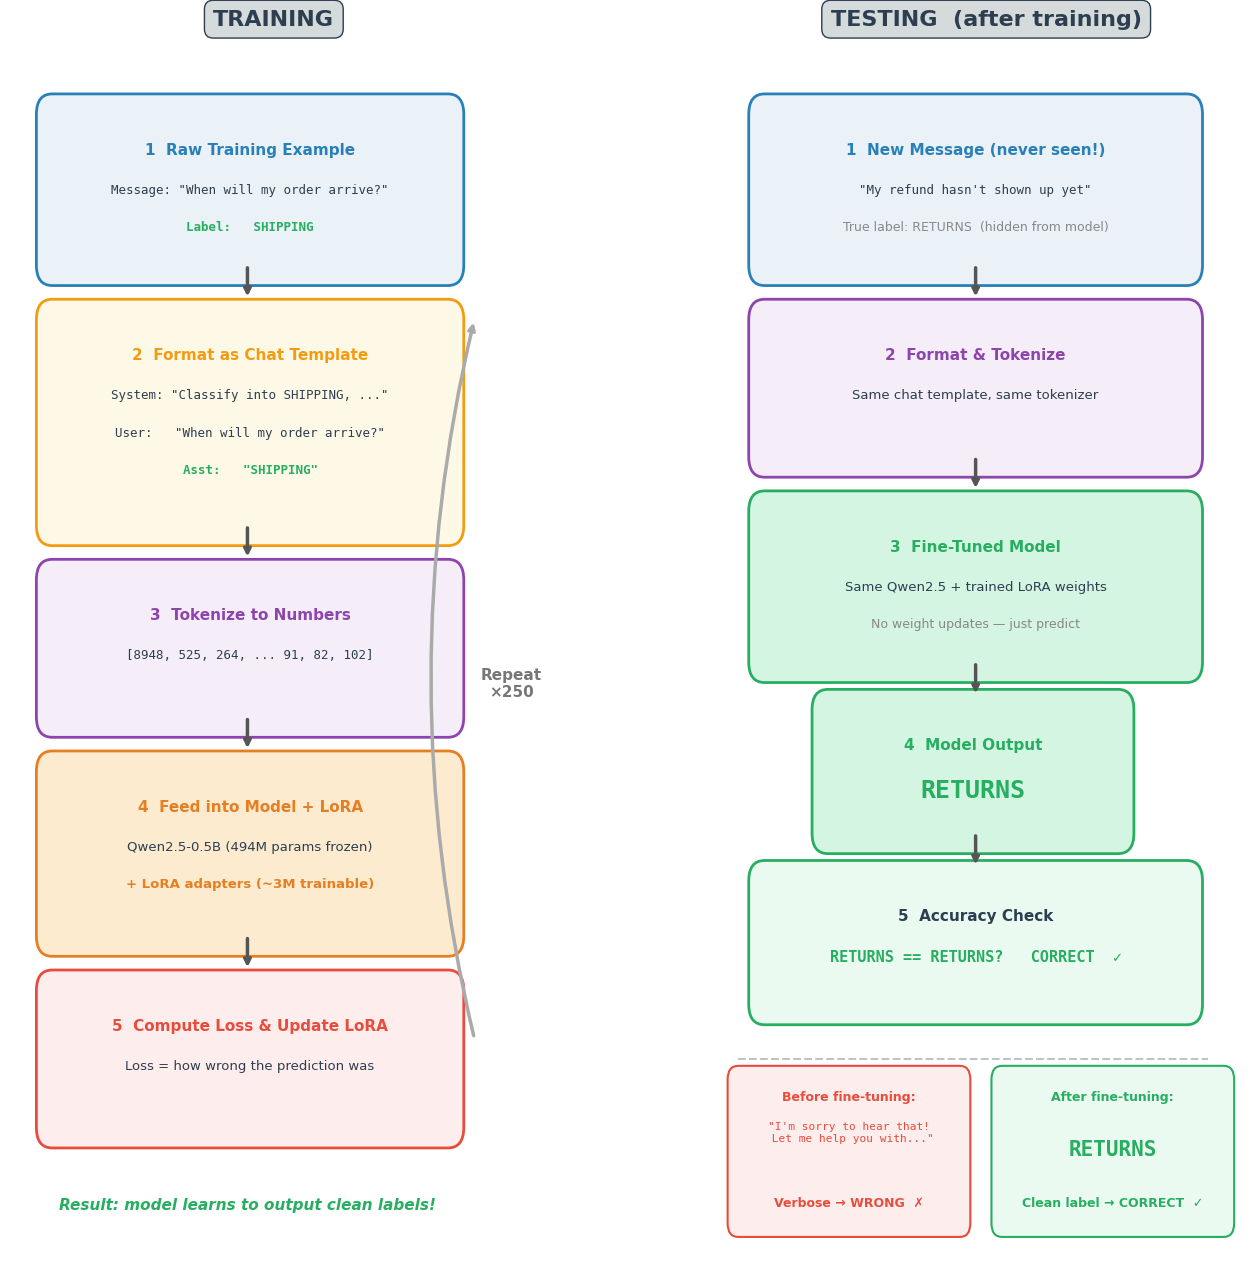

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 16), gridspec_kw={'wspace': 0.35})

def draw_box(ax, x, y, w, h, title, lines, tc, bg, ec):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.3",
                 facecolor=bg, edgecolor=ec, linewidth=2))
    ax.text(x + w/2, y + h - 0.4, title, fontsize=11, fontweight='bold', ha='center', va='top', color=tc)
    for i, L in enumerate(lines):
        ax.text(x + w/2, y + h - 1.0 - i*0.55, L[0], fontsize=L[1], ha='center', va='top',
                family='monospace' if len(L) > 2 and L[2] else 'sans-serif',
                color=L[3] if len(L) > 3 else '#2c3e50',
                fontweight=L[4] if len(L) > 4 else 'normal')

def arrow(ax, x, y1, y2):
    ax.annotate('', xy=(x, y2), xytext=(x, y1), arrowprops=dict(arrowstyle='->', lw=2.5, color='#555'))

# ======================== LEFT: TRAINING ========================
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 18); ax.axis('off')
ax.set_title('TRAINING', fontsize=16, fontweight='bold', color='#2c3e50', pad=15,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#d5dbdb', edgecolor='#2c3e50'))

draw_box(ax, 0.8, 14.8, 7.5, 2.2,
         '1  Raw Training Example',
         [('Message: "When will my order arrive?"', 9, True),
          ('Label:   SHIPPING', 9, True, '#27ae60', 'bold')],
         '#2980b9', '#eaf2f8', '#2980b9')
arrow(ax, 4.5, 14.8, 14.3)

draw_box(ax, 0.8, 11.0, 7.5, 3.0,
         '2  Format as Chat Template',
         [('System: "Classify into SHIPPING, ..."', 9, True),
          ('User:   "When will my order arrive?"', 9, True),
          ('Asst:   "SHIPPING"', 9, True, '#27ae60', 'bold')],
         '#f39c12', '#fef9e7', '#f39c12')
arrow(ax, 4.5, 11.0, 10.5)

draw_box(ax, 0.8, 8.2, 7.5, 2.0,
         '3  Tokenize to Numbers',
         [('[8948, 525, 264, ... 91, 82, 102]', 9, True)],
         '#8e44ad', '#f5eef8', '#8e44ad')
arrow(ax, 4.5, 8.2, 7.7)

draw_box(ax, 0.8, 5.0, 7.5, 2.4,
         '4  Feed into Model + LoRA',
         [('Qwen2.5-0.5B (494M params frozen)', 9.5),
          ('+ LoRA adapters (~3M trainable)', 9.5, False, '#e67e22', 'bold')],
         '#e67e22', '#fdebd0', '#e67e22')
arrow(ax, 4.5, 5.0, 4.5)

draw_box(ax, 0.8, 2.2, 7.5, 2.0,
         '5  Compute Loss & Update LoRA',
         [('Loss = how wrong the prediction was', 9.5)],
         '#e74c3c', '#fdedec', '#e74c3c')

# Repeat loop arrow on the right
ax.annotate('', xy=(8.8, 14.0), xytext=(8.8, 3.5),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#aaa', connectionstyle='arc3,rad=-0.12'))
ax.text(9.5, 8.5, 'Repeat\n×250', fontsize=11, ha='center', color='#777', fontweight='bold')

ax.text(4.5, 1.0, 'Result: model learns to output clean labels!',
        fontsize=11, ha='center', style='italic', color='#27ae60', fontweight='bold')

# ======================== RIGHT: TESTING ========================
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 18); ax.axis('off')
ax.set_title('TESTING  (after training)', fontsize=16, fontweight='bold', color='#2c3e50', pad=15,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#d5dbdb', edgecolor='#2c3e50'))

draw_box(ax, 0.8, 14.8, 8, 2.2,
         '1  New Message (never seen!)',
         [('"My refund hasn\'t shown up yet"', 9, True),
          ('True label: RETURNS  (hidden from model)', 9, False, '#888')],
         '#2980b9', '#eaf2f8', '#2980b9')
arrow(ax, 4.8, 14.8, 14.3)

draw_box(ax, 0.8, 12.0, 8, 2.0,
         '2  Format & Tokenize',
         [('Same chat template, same tokenizer', 9.5)],
         '#8e44ad', '#f5eef8', '#8e44ad')
arrow(ax, 4.8, 12.0, 11.5)

draw_box(ax, 0.8, 9.0, 8, 2.2,
         '3  Fine-Tuned Model',
         [('Same Qwen2.5 + trained LoRA weights', 9.5),
          ('No weight updates — just predict', 9, False, '#888')],
         '#27ae60', '#d5f5e3', '#27ae60')
arrow(ax, 4.8, 9.0, 8.5)

draw_box(ax, 2, 6.5, 5.5, 1.8,
         '4  Model Output',
         [('RETURNS', 18, True, '#27ae60', 'bold')],
         '#27ae60', '#d5f5e3', '#27ae60')
arrow(ax, 4.8, 6.5, 6.0)

draw_box(ax, 0.8, 4.0, 8, 1.8,
         '5  Accuracy Check',
         [('RETURNS == RETURNS?   CORRECT  ✓', 11, True, '#27ae60', 'bold')],
         '#2c3e50', '#eafaf1', '#27ae60')

# Before vs After boxes
ax.plot([0.3, 9.2], [3.2, 3.2], '--', color='#bdc3c7', lw=1.5)

ax.add_patch(mpatches.FancyBboxPatch((0.3, 0.8), 4.2, 2.1, boxstyle="round,pad=0.2",
             facecolor='#fdedec', edgecolor='#e74c3c', linewidth=1.5))
ax.text(2.4, 2.6, 'Before fine-tuning:', fontsize=9, ha='center', fontweight='bold', color='#e74c3c')
ax.text(2.4, 2.0, '"I\'m sorry to hear that!\n Let me help you with..."', fontsize=8, ha='center',
        family='monospace', color='#e74c3c')
ax.text(2.4, 1.05, 'Verbose → WRONG  ✗', fontsize=9, ha='center', fontweight='bold', color='#e74c3c')

ax.add_patch(mpatches.FancyBboxPatch((5.3, 0.8), 4.2, 2.1, boxstyle="round,pad=0.2",
             facecolor='#eafaf1', edgecolor='#27ae60', linewidth=1.5))
ax.text(7.4, 2.6, 'After fine-tuning:', fontsize=9, ha='center', fontweight='bold', color='#27ae60')
ax.text(7.4, 1.8, 'RETURNS', fontsize=15, ha='center', family='monospace', fontweight='bold', color='#27ae60')
ax.text(7.4, 1.05, 'Clean label → CORRECT  ✓', fontsize=9, ha='center', fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.show()

### Step 1: Load the Base Model (Qwen2.5-0.5B)

We load Qwen2.5-0.5B-Instruct, an efficient model from Alibaba that is openly available.

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Model configuration - Qwen2.5 is openly available
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)  # Allows running the model's custom tokenizer code from Hugging Face
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load the model
model = AutoModelForCausalLM.from_pretrained(
model_name,
torch_dtype=torch.float16,
device_map="auto",
trust_remote_code=True,
)

print(f"Model loaded: Qwen2.5-0.5B-Instruct")
print(f"Parameters: ~0.5 billion")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded: Qwen2.5-0.5B-Instruct
Parameters: ~0.5 billion


### Step 2: Prepare Training and Test Data

We have 100 customer messages, each labeled with one of 5 categories:
- **SHIPPING** — delivery tracking, shipping times, carrier questions
- **RETURNS** — refunds, exchanges, return policy
- **ACCOUNT** — login, password, profile, privacy
- **BILLING** — payments, charges, discounts, invoices
- **PRODUCT** — availability, sizing, specs, compatibility

We split them:
- **Training data** (100 examples): The model learns from these
- **Test data** (30 examples): Held out — the model never sees these during training

In [8]:
CATEGORIES = ["SHIPPING", "RETURNS", "ACCOUNT", "BILLING", "PRODUCT"]

SYSTEM_PROMPT = (
    "Classify the customer message into exactly one category: "
    "SHIPPING, RETURNS, ACCOUNT, BILLING, or PRODUCT. "
    "Respond with only the category name, nothing else."
)

# TRAINING DATA — 100 labeled customer messages (20 per category)
training_data = [
    # --- SHIPPING ---
    {"message": "When will my order arrive?", "label": "SHIPPING"},
    {"message": "How long does standard shipping take?", "label": "SHIPPING"},
    {"message": "Can I get express delivery?", "label": "SHIPPING"},
    {"message": "My tracking number isn't working", "label": "SHIPPING"},
    {"message": "Where is my package?", "label": "SHIPPING"},
    {"message": "Do you ship internationally?", "label": "SHIPPING"},
    {"message": "How much does shipping cost?", "label": "SHIPPING"},
    {"message": "Can I change my delivery address?", "label": "SHIPPING"},
    {"message": "My package says delivered but I didn't get it", "label": "SHIPPING"},
    {"message": "What carriers do you use?", "label": "SHIPPING"},
    {"message": "Is there free shipping on orders over $50?", "label": "SHIPPING"},
    {"message": "Can I track my order online?", "label": "SHIPPING"},
    {"message": "How long for international shipping?", "label": "SHIPPING"},
    {"message": "My delivery is late, what should I do?", "label": "SHIPPING"},
    {"message": "Do you ship to PO boxes?", "label": "SHIPPING"},
    {"message": "Can I get overnight shipping?", "label": "SHIPPING"},
    {"message": "Package arrived damaged during shipping", "label": "SHIPPING"},
    {"message": "What's the delivery time for California?", "label": "SHIPPING"},
    {"message": "Do you offer same-day delivery?", "label": "SHIPPING"},
    {"message": "I need to change my shipping speed after ordering", "label": "SHIPPING"},

    # --- RETURNS ---
    {"message": "I want to return this item", "label": "RETURNS"},
    {"message": "What's your return policy?", "label": "RETURNS"},
    {"message": "How do I get a refund?", "label": "RETURNS"},
    {"message": "Can I exchange this for a different size?", "label": "RETURNS"},
    {"message": "I received the wrong item and need to send it back", "label": "RETURNS"},
    {"message": "This product is defective, I want my money back", "label": "RETURNS"},
    {"message": "How long do returns take to process?", "label": "RETURNS"},
    {"message": "Is return shipping free?", "label": "RETURNS"},
    {"message": "I lost my receipt, can I still return this?", "label": "RETURNS"},
    {"message": "Can I return a sale item?", "label": "RETURNS"},
    {"message": "I want to cancel my order and get a refund", "label": "RETURNS"},
    {"message": "The item doesn't match the description", "label": "RETURNS"},
    {"message": "I changed my mind about my purchase", "label": "RETURNS"},
    {"message": "Where do I send my return package?", "label": "RETURNS"},
    {"message": "Can I return an opened product?", "label": "RETURNS"},
    {"message": "How long until I get my refund?", "label": "RETURNS"},
    {"message": "Do I need the original packaging to return?", "label": "RETURNS"},
    {"message": "I want store credit instead of a refund", "label": "RETURNS"},
    {"message": "This item arrived broken, I need a replacement", "label": "RETURNS"},
    {"message": "Can I return an online purchase in store?", "label": "RETURNS"},

    # --- ACCOUNT ---
    {"message": "I forgot my password", "label": "ACCOUNT"},
    {"message": "How do I create an account?", "label": "ACCOUNT"},
    {"message": "I can't log in to my account", "label": "ACCOUNT"},
    {"message": "How do I update my email address?", "label": "ACCOUNT"},
    {"message": "I want to delete my account", "label": "ACCOUNT"},
    {"message": "How do I change my password?", "label": "ACCOUNT"},
    {"message": "Is my personal information secure?", "label": "ACCOUNT"},
    {"message": "How do I unsubscribe from marketing emails?", "label": "ACCOUNT"},
    {"message": "Can I merge two accounts?", "label": "ACCOUNT"},
    {"message": "My account was locked after too many attempts", "label": "ACCOUNT"},
    {"message": "How do I update my phone number?", "label": "ACCOUNT"},
    {"message": "Do you offer two-factor authentication?", "label": "ACCOUNT"},
    {"message": "Someone else accessed my account", "label": "ACCOUNT"},
    {"message": "How do I download my personal data?", "label": "ACCOUNT"},
    {"message": "I want to change my billing address on file", "label": "ACCOUNT"},
    {"message": "How do I view my order history?", "label": "ACCOUNT"},
    {"message": "How do I set up email notifications?", "label": "ACCOUNT"},
    {"message": "My account settings won't save", "label": "ACCOUNT"},
    {"message": "I need to update my profile picture", "label": "ACCOUNT"},
    {"message": "How do I link my social media account?", "label": "ACCOUNT"},

    # --- BILLING ---
    {"message": "What payment methods do you accept?", "label": "BILLING"},
    {"message": "My credit card was charged twice", "label": "BILLING"},
    {"message": "How do I apply a promo code?", "label": "BILLING"},
    {"message": "Can I pay with PayPal?", "label": "BILLING"},
    {"message": "I was charged the wrong amount", "label": "BILLING"},
    {"message": "Do you offer installment payments?", "label": "BILLING"},
    {"message": "Where is my receipt?", "label": "BILLING"},
    {"message": "Can I get a price adjustment?", "label": "BILLING"},
    {"message": "My payment was declined", "label": "BILLING"},
    {"message": "Do you charge sales tax?", "label": "BILLING"},
    {"message": "How do I update my credit card on file?", "label": "BILLING"},
    {"message": "I need an invoice for my purchase", "label": "BILLING"},
    {"message": "Can I split payment between two cards?", "label": "BILLING"},
    {"message": "Do you accept gift cards as payment?", "label": "BILLING"},
    {"message": "When will I be charged for my pre-order?", "label": "BILLING"},
    {"message": "I have a billing dispute", "label": "BILLING"},
    {"message": "Can I get a student discount?", "label": "BILLING"},
    {"message": "How do I redeem store credit?", "label": "BILLING"},
    {"message": "My coupon code isn't working", "label": "BILLING"},
    {"message": "Do you offer military discounts?", "label": "BILLING"},

    # --- PRODUCT ---
    {"message": "Is this product in stock?", "label": "PRODUCT"},
    {"message": "What sizes do you carry?", "label": "PRODUCT"},
    {"message": "Can I see more photos of this item?", "label": "PRODUCT"},
    {"message": "What materials is this made from?", "label": "PRODUCT"},
    {"message": "Is this product waterproof?", "label": "PRODUCT"},
    {"message": "Do you have this in a different color?", "label": "PRODUCT"},
    {"message": "What are the exact dimensions?", "label": "PRODUCT"},
    {"message": "Is this compatible with my iPhone?", "label": "PRODUCT"},
    {"message": "When will this item be back in stock?", "label": "PRODUCT"},
    {"message": "Can I customize this product?", "label": "PRODUCT"},
    {"message": "What's the warranty on this item?", "label": "PRODUCT"},
    {"message": "Are your products eco-friendly?", "label": "PRODUCT"},
    {"message": "Do you have a size guide?", "label": "PRODUCT"},
    {"message": "What's the difference between these two models?", "label": "PRODUCT"},
    {"message": "Is this item currently on sale?", "label": "PRODUCT"},
    {"message": "Can I buy this as a gift with wrapping?", "label": "PRODUCT"},
    {"message": "What's the weight of this product?", "label": "PRODUCT"},
    {"message": "Does this come with batteries included?", "label": "PRODUCT"},
    {"message": "Is this suitable for children under 5?", "label": "PRODUCT"},
    {"message": "Where can I read customer reviews?", "label": "PRODUCT"},
]

# TEST DATA — 30 held-out messages (6 per category)
test_data = [
    {"message": "Why hasn't my order shipped yet?", "label": "SHIPPING"},
    {"message": "Can I pick up my order at a store?", "label": "SHIPPING"},
    {"message": "What happens if I miss the delivery?", "label": "SHIPPING"},
    {"message": "How do I change my delivery date?", "label": "SHIPPING"},
    {"message": "My package is stuck in transit for 5 days", "label": "SHIPPING"},
    {"message": "Do you deliver on weekends?", "label": "SHIPPING"},

    {"message": "I'd like to request a return label", "label": "RETURNS"},
    {"message": "Can I return something after 30 days?", "label": "RETURNS"},
    {"message": "My refund hasn't shown up on my statement yet", "label": "RETURNS"},
    {"message": "Is there a restocking fee for returns?", "label": "RETURNS"},
    {"message": "I received a damaged product and want to exchange it", "label": "RETURNS"},
    {"message": "Do you accept returns on electronic items?", "label": "RETURNS"},

    {"message": "How do I recover my account?", "label": "ACCOUNT"},
    {"message": "Can I change the name on my account?", "label": "ACCOUNT"},
    {"message": "My verification email never arrived", "label": "ACCOUNT"},
    {"message": "How do I permanently close my account?", "label": "ACCOUNT"},
    {"message": "I accidentally created a duplicate account", "label": "ACCOUNT"},
    {"message": "Are my saved addresses secure?", "label": "ACCOUNT"},

    {"message": "Why is there a pending charge on my card?", "label": "BILLING"},
    {"message": "Do you accept cryptocurrency?", "label": "BILLING"},
    {"message": "My gift card balance seems wrong", "label": "BILLING"},
    {"message": "How do I get a tax-exempt receipt?", "label": "BILLING"},
    {"message": "Can I use two discount codes together?", "label": "BILLING"},
    {"message": "When does the charge appear on my bank statement?", "label": "BILLING"},

    {"message": "How do I know what size to order?", "label": "PRODUCT"},
    {"message": "Is this product cruelty-free?", "label": "PRODUCT"},
    {"message": "What's the battery life on this device?", "label": "PRODUCT"},
    {"message": "Do you sell replacement parts?", "label": "PRODUCT"},
    {"message": "Is this product dishwasher safe?", "label": "PRODUCT"},
    {"message": "What's the shelf life of this product?", "label": "PRODUCT"},
]

print(f"Training data: {len(training_data)} messages")
for cat in CATEGORIES:
    n = sum(1 for x in training_data if x['label'] == cat)
    print(f"  {cat}: {n} examples")
print(f"\nTest data: {len(test_data)} messages (held out)")
for cat in CATEGORIES:
    n = sum(1 for x in test_data if x['label'] == cat)
    print(f"  {cat}: {n} examples")

Training data: 100 messages
  SHIPPING: 20 examples
  RETURNS: 20 examples
  ACCOUNT: 20 examples
  BILLING: 20 examples
  PRODUCT: 20 examples

Test data: 30 messages (held out)
  SHIPPING: 6 examples
  RETURNS: 6 examples
  ACCOUNT: 6 examples
  BILLING: 6 examples
  PRODUCT: 6 examples


## 5. BEFORE Fine-Tuning: Baseline Evaluation

Before we fine-tune, let's see how the base model handles classification. We give it the same system prompt ("classify into SHIPPING, RETURNS, ACCOUNT, BILLING, or PRODUCT") and see how well it performs without any task-specific training.

**Evaluation metric: Accuracy** — the percentage of test messages where the model's output contains the correct category label. Simple and unambiguous.

### How the Scoring Works

For each test message, we check whether the model's output **contains** the correct category label.

> **Message**: "Why hasn't my order shipped yet?"
> **Expected label**: SHIPPING
>
> If the model outputs: *"Based on your question about order delivery, this falls under the SHIPPING category..."*
> → **Correct** (contains "SHIPPING")
>
> If the model outputs: *"I'd be happy to help you with your order status! Let me look into that..."*
> → **Wrong** (doesn't contain any category label)

A well-fine-tuned model should output just `SHIPPING` — clean, fast, and easy to route programmatically.

In [9]:
def generate_response(model, tokenizer, message):
    """Generate a classification response from the model"""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": message}
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def match_category(generated_text):
    """Match model output to a category, handling variations like RETURN→RETURNS."""
    text = generated_text.upper()

    # First: exact match (e.g., "RETURNS" in output)
    for cat in CATEGORIES:
        if cat in text:
            return cat

    # Second: match singular forms (e.g., "RETURN" should count as "RETURNS")
    singular_map = {"RETURN": "RETURNS", "SHIP": "SHIPPING", "ACCOUNT": "ACCOUNT",
                    "BILL": "BILLING", "PRODUCT": "PRODUCT"}
    for singular, full in singular_map.items():
        if singular in text:
            return full

    return None

def evaluate_on_test_data(model, tokenizer, test_data):
    """Evaluate classification accuracy on held-out test data."""
    results = []
    correct = 0

    for item in test_data:
        generated = generate_response(model, tokenizer, item["message"])
        expected = item["label"]
        predicted = match_category(generated)
        is_correct = predicted == expected
        correct += is_correct

        results.append({
            "message": item["message"], "expected": expected,
            "predicted": predicted, "generated": generated,
            "correct": is_correct
        })

    accuracy = correct / len(test_data)
    return results, accuracy

print("Evaluating BEFORE fine-tuning on TEST DATA...\n")
before_results, before_score = evaluate_on_test_data(model, tokenizer, test_data)

print(f"BASELINE ACCURACY: {before_score:.1%} ({sum(r['correct'] for r in before_results)}/{len(test_data)} correct)")
print("=" * 60)
for r in before_results[:8]:
    status = "correct" if r["correct"] else "WRONG"
    print(f"  Message: \"{r['message'][:55]}\"")
    print(f"  Expected: {r['expected']} | Model said: \"{r['generated'][:60]}\" → {status}")
    print()

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Evaluating BEFORE fine-tuning on TEST DATA...

BASELINE ACCURACY: 53.3% (16/30 correct)
  Message: "Why hasn't my order shipped yet?"
  Expected: SHIPPING | Model said: "ACCOUNT" → WRONG

  Message: "Can I pick up my order at a store?"
  Expected: SHIPPING | Model said: "BILLING" → WRONG

  Message: "What happens if I miss the delivery?"
  Expected: SHIPPING | Model said: "RETURN" → WRONG

  Message: "How do I change my delivery date?"
  Expected: SHIPPING | Model said: "BILLING" → WRONG

  Message: "My package is stuck in transit for 5 days"
  Expected: SHIPPING | Model said: "ACCOUNT" → WRONG

  Message: "Do you deliver on weekends?"
  Expected: SHIPPING | Model said: "RETURN" → WRONG

  Message: "I'd like to request a return label"
  Expected: RETURNS | Model said: "RETURN" → correct

  Message: "Can I return something after 30 days?"
  Expected: RETURNS | Model said: "RETURN" → correct



## 6. Add LoRA Adapters and Train

Now we apply LoRA adapters to the model and train on our 100 customer service examples.

Recall that LoRA freezes the original model and adds small trainable layers on top. Below you will see that only about 1% of the total parameters are being updated — the rest stay fixed. This is what makes fine-tuning practical.

### Understanding the LoRA Configuration

Each parameter below controls a different aspect of the fine-tuning:

| Parameter | Value | What it means |
|-----------|-------|--------------|
| `r` (rank) | 16 | Size of the adapter matrices. Higher = more capacity to learn, but more parameters. Think of it as: "how many sticky notes can I add?" |
| `lora_alpha` | 32 | Scaling factor that controls how strongly the adapters influence the output. The effective scale is `alpha/r` = 2.0 |
| `target_modules` | q, k, v, o projections | Which layers of the transformer get adapters. These are the **attention layers** — the parts that decide what to focus on |
| `lora_dropout` | 0.05 | 5% chance of randomly "turning off" adapter neurons during training. Prevents overfitting (like the exam analogy) |
| `bias` | "none" | Don't train the bias terms — keeps things lightweight |

The key trade-off: **higher `r`** = more powerful adapters but more parameters to train and more risk of overfitting on small datasets.

In [10]:
from peft import LoraConfig, get_peft_model, TaskType

# LoRA configuration
lora_config = LoraConfig(
    r=16,                # Rank of adapter matrices (higher = more capacity but more params)
    lora_alpha=32,       # Scaling factor — controls how much the adapters influence the output
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],  # Which layers get adapters
    lora_dropout=0.05,   # Regularization to prevent overfitting
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"LoRA adapters added!")
print(f"Original model:  {total_params:>12,} parameters")
print(f"Trainable (LoRA): {trainable_params:>11,} parameters ({100*trainable_params/total_params:.2f}%)")
print(f"Frozen:           {total_params - trainable_params:>11,} parameters ({100*(total_params - trainable_params)/total_params:.2f}%)")

LoRA adapters added!
Original model:   496,195,456 parameters
Trainable (LoRA):   2,162,688 parameters (0.44%)
Frozen:           494,032,768 parameters (99.56%)


In [11]:
from datasets import Dataset

def format_and_tokenize(example):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": example['message']},
        {"role": "assistant", "content": example['label']}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False)
    tokens = tokenizer(text, truncation=True, max_length=256, padding="max_length", return_tensors=None)
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

dataset = Dataset.from_list(training_data)
tokenized_dataset = dataset.map(format_and_tokenize, remove_columns=dataset.column_names)

print(f"Dataset ready: {len(tokenized_dataset)} training examples")

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset ready: 100 training examples


In [12]:
# Let's peek at what one training example looks like AFTER formatting
# This is what the model actually "sees" during training

example = training_data[0]
print("=== RAW DATA ===")
print(f'  Message: "{example["message"]}"')
print(f'  Label:   "{example["label"]}"')

# Format it the same way as training
messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": example['message']},
    {"role": "assistant", "content": example['label']}
]
formatted = tokenizer.apply_chat_template(messages, tokenize=False)

print("\n=== FORMATTED AS CHAT TEMPLATE ===")
print(formatted)

# Show token IDs
tokens = tokenizer(formatted, return_tensors=None)
print(f"\n=== TOKENIZED ===")
print(f"  Total tokens: {len(tokens['input_ids'])}")
print(f"  First 20 token IDs: {tokens['input_ids'][:20]}")

decoded_tokens = [tokenizer.decode([t]) for t in tokens['input_ids'][:20]]
print(f"  Decoded:            {decoded_tokens}")
print(f"\n  The model learns from {len(tokenized_dataset)} examples formatted like this.")

=== RAW DATA ===
  Message: "When will my order arrive?"
  Label:   "SHIPPING"

=== FORMATTED AS CHAT TEMPLATE ===
<|im_start|>system
Classify the customer message into exactly one category: SHIPPING, RETURNS, ACCOUNT, BILLING, or PRODUCT. Respond with only the category name, nothing else.<|im_end|>
<|im_start|>user
When will my order arrive?<|im_end|>
<|im_start|>assistant
SHIPPING<|im_end|>


=== TOKENIZED ===
  Total tokens: 55
  First 20 token IDs: [151644, 8948, 198, 1957, 1437, 279, 6002, 1943, 1119, 6896, 825, 5582, 25, 87318, 11, 68039, 11, 62358, 11, 92646]
  Decoded:            ['<|im_start|>', 'system', '\n', 'Class', 'ify', ' the', ' customer', ' message', ' into', ' exactly', ' one', ' category', ':', ' SHIPPING', ',', ' RETURNS', ',', ' ACCOUNT', ',', ' BILL']

  The model learns from 100 examples formatted like this.


In [13]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling, TrainerCallback

# Custom callback to track training metrics
class TrainingMetricsCallback(TrainerCallback):
    def __init__(self):
        self.training_loss = []
        self.steps = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.training_loss.append(logs["loss"])
            self.steps.append(state.global_step)

metrics_callback = TrainingMetricsCallback()

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Training configuration
training_args = TrainingArguments(
    output_dir="./customer_service_qwen",
    num_train_epochs=5,                # 5 epochs: enough to learn without heavy overfitting
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,                # LoRA can handle higher LR than full fine-tuning
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    fp16=True,
    warmup_steps=10,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
    callbacks=[metrics_callback],
)

print("Starting training for 5 epochs...")
print(f"  Training examples: {len(tokenized_dataset)}")
print(f"  Learning rate: 2e-4 (higher than typical — LoRA adapters can learn faster)")
print("  Watch the loss decrease!\n")

Starting training for 5 epochs...
  Training examples: 100
  Learning rate: 2e-4 (higher than typical — LoRA adapters can learn faster)
  Watch the loss decrease!



In [14]:
# Run training
train_result = trainer.train()

# Get the last logged loss (not the average over all steps)
last_loss = metrics_callback.training_loss[-1] if metrics_callback.training_loss else train_result.training_loss

print(f"\nTraining complete!")
print(f"Final step loss: {last_loss:.4f}")
print(f"(Average loss across all steps: {train_result.training_loss:.4f} — includes early high-loss steps)")

Step,Training Loss
10,3.739791
20,1.215162
30,0.351914
40,0.345674
50,0.344018
60,0.313779
70,0.303279
80,0.237386
90,0.294256
100,0.266246



Training complete!
Final step loss: 0.1614
(Average loss across all steps: 0.4067 — includes early high-loss steps)


## 7. Visualize Training Loss

### What is the loss, exactly?

LLMs are trained to **predict the next token** (word/subword). The loss measures how surprised the model is by the correct answer — technically, it's the **cross-entropy** between the model's predicted probability distribution and the actual next token.

### Token-level loss

During fine-tuning, the loss is computed **only on the completion tokens** (after `<assistant>`), not on the prompt. Here's one training example broken into tokens:

```
 Token position:   1        2        3      ...    48       49       50      51
 Token:          <system> Classify  into    ...  arrive?  <asst>   SHIP    PING
                                                                    ↑       ↑
                                                                  loss₅₀  loss₅₁
```

**Total loss = average of completion-token losses** = (loss₅₀ + loss₅₁) / 2

Note that:
- A single word like `SHIPPING` may be split into **multiple tokens** (`SHIP` + `PING`) by the tokenizer
- Loss is computed **only on the completion tokens** (after `<assistant>`) — the prompt tokens are masked out and do not contribute to the loss or gradients
- The label tokens (like `SHIP` and `PING` after `<assistant>`) are where all the learning happens

### Concrete example

| Model sees | Must predict | Before training | After training |
|-----------|-------------|-----------------|----------------|
| `...arrive? <assistant>` | `SHIP` | 2% → **loss = 3.9** | 85% → **loss = 0.2** |
| `...<assistant> SHIP` | `PING` | 5% → loss = 3.0 | 90% → loss = 0.1 |

**Per-token loss = −log(probability of correct token)**. If the model assigns 90% probability → loss = 0.1 (good). If only 2% → loss = 3.9 (bad).

The reported loss number (e.g., 0.16 at step 250) is the **average across the completion tokens** in that training example.

What to look for in the plot below:
- **Decreasing curve**: Good — the model is learning
- **Flattening out**: The model has learned most of what it can from this data
- **Going back up**: Warning sign — possible **overfitting**

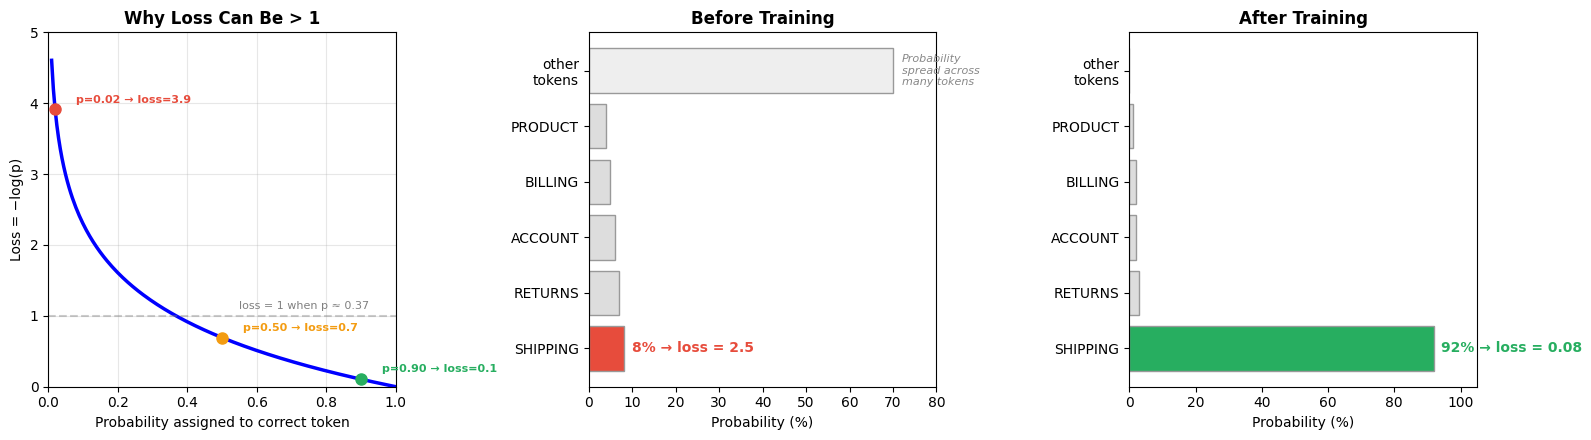

Key insight: loss = −log(probability).
  • Probability is between 0 and 1, but loss ranges from 0 to ∞
  • Low probability (model is wrong) → high loss  (punished heavily)
  • High probability (model is right) → low loss  (small reward)
  • This is why the first training steps show loss ~3.7 — the model
    was assigning <3% probability to the correct label!


In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Left: -log(p) curve ---
p = np.linspace(0.01, 1.0, 200)
loss = -np.log(p)

axes[0].plot(p, loss, 'b-', linewidth=2.5)
axes[0].set_xlabel('Probability assigned to correct token', fontsize=10)
axes[0].set_ylabel('Loss = −log(p)', fontsize=10)
axes[0].set_title('Why Loss Can Be > 1', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 5)
axes[0].grid(True, alpha=0.3)

# Annotate key points
for prob, label, color in [(0.02, 'p=0.02 → loss=3.9', '#e74c3c'),
                             (0.50, 'p=0.50 → loss=0.7', '#f39c12'),
                             (0.90, 'p=0.90 → loss=0.1', '#27ae60')]:
    y = -np.log(prob)
    axes[0].plot(prob, y, 'o', color=color, markersize=8, zorder=5)
    axes[0].annotate(label, (prob, y), textcoords="offset points",
                     xytext=(15, 5), fontsize=8, color=color, fontweight='bold')

axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.4)
axes[0].text(0.55, 1.1, 'loss = 1 when p ≈ 0.37', fontsize=8, color='gray')

# --- Middle: Before training — model is confused ---
categories = ['SHIPPING', 'RETURNS', 'ACCOUNT', 'BILLING', 'PRODUCT', 'other\ntokens']
probs_before = [8, 7, 6, 5, 4, 70]
colors_before = ['#e74c3c', '#ddd', '#ddd', '#ddd', '#ddd', '#eee']

axes[1].barh(categories, probs_before, color=colors_before, edgecolor='#999')
axes[1].set_xlabel('Probability (%)', fontsize=10)
axes[1].set_title('Before Training', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 80)
axes[1].text(10, 0, '8% → loss = 2.5', fontsize=10, va='center', color='#e74c3c', fontweight='bold')
axes[1].text(72, 5, 'Probability\nspread across\nmany tokens', fontsize=8, va='center', color='#888', style='italic')

# --- Right: After training — model is confident ---
probs_after = [92, 3, 2, 2, 1, 0]
colors_after = ['#27ae60', '#ddd', '#ddd', '#ddd', '#ddd', '#eee']

axes[2].barh(categories, probs_after, color=colors_after, edgecolor='#999')
axes[2].set_xlabel('Probability (%)', fontsize=10)
axes[2].set_title('After Training', fontsize=12, fontweight='bold')
axes[2].set_xlim(0, 105)
axes[2].text(94, 0, '92% → loss = 0.08', fontsize=10, va='center', color='#27ae60', fontweight='bold')

plt.tight_layout()
plt.show()

print("Key insight: loss = −log(probability).")
print("  • Probability is between 0 and 1, but loss ranges from 0 to ∞")
print("  • Low probability (model is wrong) → high loss  (punished heavily)")
print("  • High probability (model is right) → low loss  (small reward)")
print("  • This is why the first training steps show loss ~3.7 — the model")
print("    was assigning <3% probability to the correct label!")

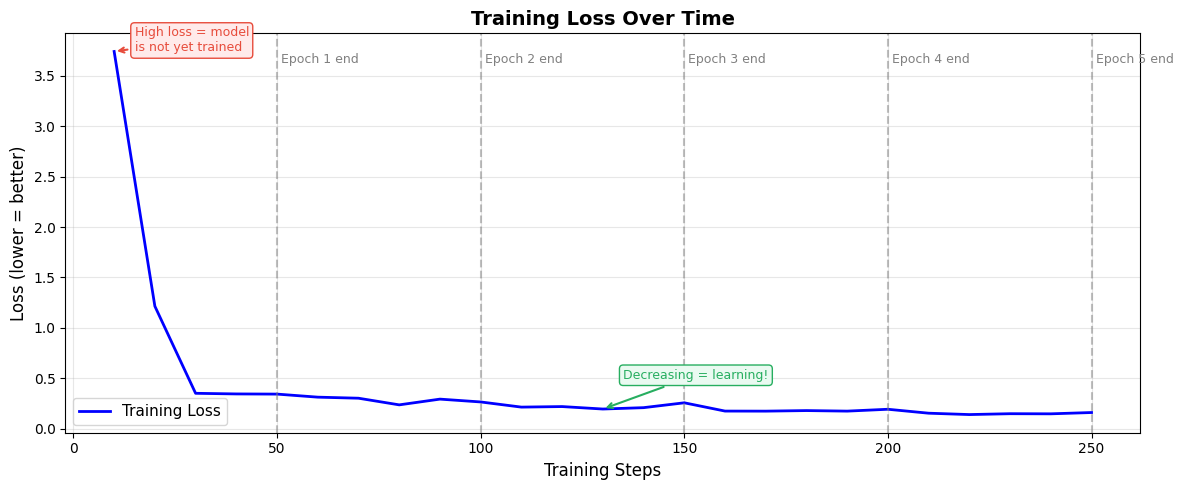


How to read this chart:
  - Loss starts HIGH = the model doesn't know your domain yet
  - Loss DECREASES = the model is learning from your examples
  - Loss FLATTENS = the model has learned most of what it can
  - Loss goes UP = warning! The model may be overfitting (memorizing, not learning)


In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

# Plot training loss
ax.plot(metrics_callback.steps, metrics_callback.training_loss, 'b-', linewidth=2, label='Training Loss')

# Add epoch markers
steps_per_epoch = len(tokenized_dataset) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
if steps_per_epoch > 0:
    for epoch in range(1, int(training_args.num_train_epochs) + 1):
        epoch_step = epoch * steps_per_epoch
        if epoch_step <= max(metrics_callback.steps):
            ax.axvline(x=epoch_step, color='gray', linestyle='--', alpha=0.5)
            ax.text(epoch_step, ax.get_ylim()[1] * 0.95, f' Epoch {epoch} end',
                    fontsize=9, color='gray', va='top')

# Annotate key regions
if len(metrics_callback.training_loss) > 2:
    # Starting point annotation
    ax.annotate('High loss = model\nis not yet trained', xy=(metrics_callback.steps[0], metrics_callback.training_loss[0]),
                xytext=(metrics_callback.steps[0] + 5, metrics_callback.training_loss[0]),
                fontsize=9, color='#e74c3c',
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffeaea', edgecolor='#e74c3c'))

    # End point annotation
    last_idx = len(metrics_callback.training_loss) - 1
    mid_idx = last_idx // 2
    ax.annotate('Decreasing = learning!', xy=(metrics_callback.steps[mid_idx], metrics_callback.training_loss[mid_idx]),
                xytext=(metrics_callback.steps[mid_idx] + 5, metrics_callback.training_loss[mid_idx] + 0.3),
                fontsize=9, color='#27ae60',
                arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#27ae60'))

ax.set_xlabel('Training Steps', fontsize=12)
ax.set_ylabel('Loss (lower = better)', fontsize=12)
ax.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHow to read this chart:")
print("  - Loss starts HIGH = the model doesn't know your domain yet")
print("  - Loss DECREASES = the model is learning from your examples")
print("  - Loss FLATTENS = the model has learned most of what it can")
print("  - Loss goes UP = warning! The model may be overfitting (memorizing, not learning)")

## 8. AFTER Fine-Tuning: Measure Real Improvement

Now we run the exact same evaluation on the exact same held-out test questions — but using the fine-tuned model instead of the original. By comparing the before and after scores, we can see whether fine-tuning actually improved the model's ability to answer questions it was never trained on.

In [17]:
model.eval()

print("Evaluating AFTER fine-tuning on TEST DATA...\n")
after_results, after_score = evaluate_on_test_data(model, tokenizer, test_data)

print(f"AFTER ACCURACY: {after_score:.1%} ({sum(r['correct'] for r in after_results)}/{len(test_data)} correct)")
print("=" * 60)
for r in after_results[:8]:
    status = "correct" if r["correct"] else "WRONG"
    print(f"  Message: \"{r['message'][:55]}\"")
    print(f"  Expected: {r['expected']} | Model said: \"{r['generated'][:40]}\" → {status}")
    print()

Evaluating AFTER fine-tuning on TEST DATA...

AFTER ACCURACY: 96.7% (29/30 correct)
  Message: "Why hasn't my order shipped yet?"
  Expected: SHIPPING | Model said: "SHIPPING" → correct

  Message: "Can I pick up my order at a store?"
  Expected: SHIPPING | Model said: "SHIPPING" → correct

  Message: "What happens if I miss the delivery?"
  Expected: SHIPPING | Model said: "SHIPPING" → correct

  Message: "How do I change my delivery date?"
  Expected: SHIPPING | Model said: "SHIPPING" → correct

  Message: "My package is stuck in transit for 5 days"
  Expected: SHIPPING | Model said: "SHIPPING" → correct

  Message: "Do you deliver on weekends?"
  Expected: SHIPPING | Model said: "SHIPPING" → correct

  Message: "I'd like to request a return label"
  Expected: RETURNS | Model said: "RETURNS" → correct

  Message: "Can I return something after 30 days?"
  Expected: RETURNS | Model said: "RETURNS" → correct



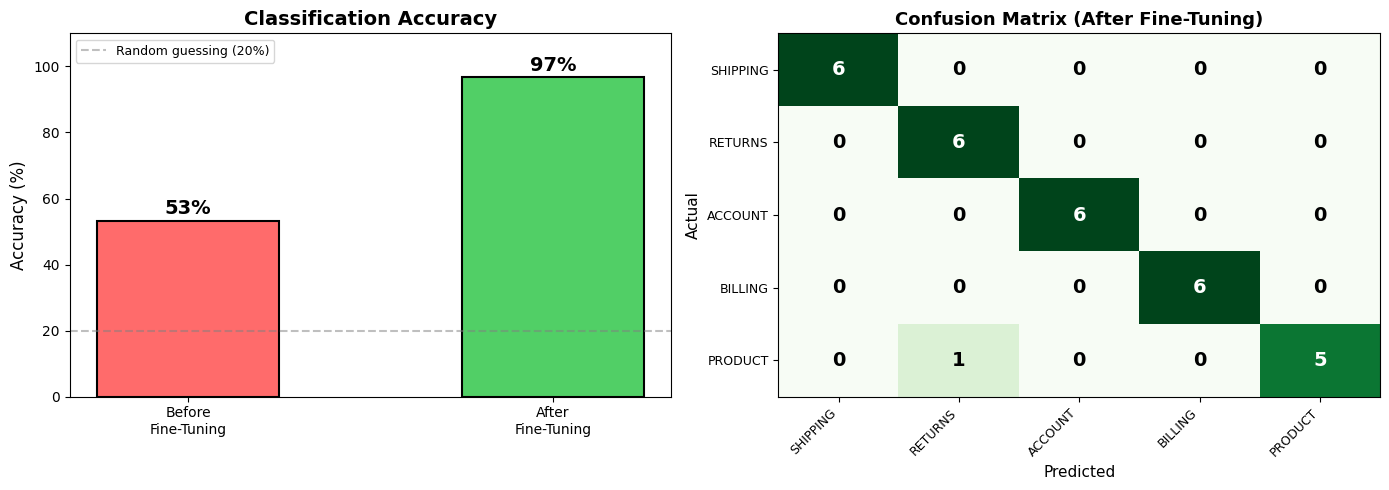


  BEFORE fine-tuning: 53.3%
  AFTER  fine-tuning: 96.7%
  IMPROVEMENT:        +43.3%


In [18]:
# Visualize before/after comparison
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Accuracy bar chart ---
scores = [before_score * 100, after_score * 100]
labels = ['Before\nFine-Tuning', 'After\nFine-Tuning']
colors = ['#ff6b6b', '#51cf66']

bars = axes[0].bar(labels, scores, color=colors, edgecolor='black', linewidth=1.5, width=0.5)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Classification Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 110)
for i, v in enumerate(scores):
    axes[0].text(i, v + 2, f'{v:.0f}%', ha='center', fontsize=14, fontweight='bold')
# Random baseline
axes[0].axhline(y=20, color='gray', linestyle='--', alpha=0.5, label='Random guessing (20%)')
axes[0].legend(fontsize=9)

# --- Panel 2: Confusion matrix for AFTER results ---
from collections import Counter
conf = np.zeros((len(CATEGORIES), len(CATEGORIES)), dtype=int)
for r in after_results:
    true_idx = CATEGORIES.index(r['expected'])
    pred_idx = CATEGORIES.index(r['predicted']) if r['predicted'] in CATEGORIES else -1
    if pred_idx >= 0:
        conf[true_idx][pred_idx] += 1

im = axes[1].imshow(conf, cmap='Greens', aspect='auto')
axes[1].set_xticks(range(len(CATEGORIES)))
axes[1].set_xticklabels(CATEGORIES, fontsize=9, rotation=45, ha='right')
axes[1].set_yticks(range(len(CATEGORIES)))
axes[1].set_yticklabels(CATEGORIES, fontsize=9)
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_title('Confusion Matrix (After Fine-Tuning)', fontsize=13, fontweight='bold')

for i in range(len(CATEGORIES)):
    for j in range(len(CATEGORIES)):
        color = 'white' if conf[i][j] > 3 else 'black'
        axes[1].text(j, i, str(conf[i][j]), ha='center', va='center', fontsize=14, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

improvement = after_score - before_score
print(f"\n{'='*60}")
print(f"  BEFORE fine-tuning: {before_score:.1%}")
print(f"  AFTER  fine-tuning: {after_score:.1%}")
print(f"  IMPROVEMENT:        +{improvement:.1%}")
print(f"{'='*60}")

In [19]:
# Side-by-side: how the model's output changed after fine-tuning
from IPython.display import HTML

html = "<h3>Before vs After: What the Model Actually Outputs</h3>"
html += "<table style='width:100%; border-collapse:collapse; font-size:12px;'>"
html += "<tr style='background:#2c3e50; color:white;'>"
html += "<th style='padding:8px; border:1px solid #ddd; width:25%'>Customer Message</th>"
html += "<th style='padding:8px; border:1px solid #ddd; width:8%'>True Label</th>"
html += "<th style='padding:8px; border:1px solid #ddd; width:33%'>Before Fine-Tuning</th>"
html += "<th style='padding:8px; border:1px solid #ddd; width:33%'>After Fine-Tuning</th></tr>"

for b, a in zip(before_results[:10], after_results[:10]):
    b_bg = '#f0fff0' if b['correct'] else '#fff5f5'
    a_bg = '#f0fff0' if a['correct'] else '#fff5f5'
    html += f"<tr>"
    html += f"<td style='padding:6px; border:1px solid #ddd;'>{b['message']}</td>"
    html += f"<td style='padding:6px; border:1px solid #ddd; font-weight:bold;'>{b['expected']}</td>"
    html += f"<td style='padding:6px; border:1px solid #ddd; background:{b_bg};'>{b['generated'][:80]}</td>"
    html += f"<td style='padding:6px; border:1px solid #ddd; background:{a_bg};'>{a['generated'][:80]}</td>"
    html += "</tr>"

html += "</table>"
html += "<p style='font-size:11px; color:gray;'>Green = correct classification, Red = wrong</p>"
display(HTML(html))

Customer Message,True Label,Before Fine-Tuning,After Fine-Tuning
Why hasn't my order shipped yet?,SHIPPING,ACCOUNT,SHIPPING
Can I pick up my order at a store?,SHIPPING,BILLING,SHIPPING
What happens if I miss the delivery?,SHIPPING,RETURN,SHIPPING
How do I change my delivery date?,SHIPPING,BILLING,SHIPPING
My package is stuck in transit for 5 days,SHIPPING,ACCOUNT,SHIPPING
Do you deliver on weekends?,SHIPPING,RETURN,SHIPPING
I'd like to request a return label,RETURNS,RETURN,RETURNS
Can I return something after 30 days?,RETURNS,RETURN,RETURNS
My refund hasn't shown up on my statement yet,RETURNS,BILLING,RETURNS
Is there a restocking fee for returns?,RETURNS,RETURN,RETURNS


## 9. Test with Your Own Questions

In [20]:
new_messages = [
    "I need help with a refund for my broken headphones",
    "What time does the store open on Saturday?",
    "My promo code SAVE20 isn't applying at checkout",
    "Is the blue version of this jacket available in medium?",
    "I think someone hacked into my account last night",
]

print("Testing with completely NEW messages:\n")
for msg in new_messages:
    response = generate_response(model, tokenizer, msg)
    print(f"  Message: \"{msg}\"")
    print(f"  → {response}")
    print()

Testing with completely NEW messages:

  Message: "I need help with a refund for my broken headphones"
  → RETURNS

  Message: "What time does the store open on Saturday?"
  → SHIPPING

  Message: "My promo code SAVE20 isn't applying at checkout"
  → BILLING

  Message: "Is the blue version of this jacket available in medium?"
  → PRODUCT

  Message: "I think someone hacked into my account last night"
  → ACCOUNT



## 10. Save the Model (Optional)

In [21]:
model.save_pretrained("customer_service_lora")
tokenizer.save_pretrained("customer_service_lora")
print("Model saved!")
!du -sh customer_service_lora/

Model saved!
20M	customer_service_lora/


## 11. Summary & Key Takeaways

### What We Learned

1. **Fine-tuning** adapts a pre-trained model to your specific task
2. **LoRA** makes fine-tuning efficient (train only ~1% of parameters)
3. **Classification tasks** show dramatic improvement — the model learns to output structured labels instead of verbose responses
4. **Training curves** help you monitor learning and detect overfitting
5. **Train/Test split** is essential to measure real improvement on unseen data

### What We Did

- Loaded Qwen2.5-0.5B (0.5 billion parameters)
- Trained it to classify customer messages into 5 categories
- Used LoRA adapters (only ~1% of parameters trainable)
- Accuracy improved after fine-tuning on task-specific data
- Visualized improvement with accuracy charts and confusion matrix

### Business Application

This is exactly how companies automate customer service routing — classify incoming messages and send them to the right department. Fine-tuning a small model is cheaper and faster than sending every message to a large API like GPT-4.

---

*Questions? Reach out during office hours.*